### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


### **Load Dataset**

In [2]:
df = pd.read_csv('titanic.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **Basic Info**

In [3]:
print("Column Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nDataset Info:")
df.info()

Column Names:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 no

### **Statistical Summary**

In [4]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### **Missing Values**

In [5]:
print("Missing Values:\n")
print(df.isnull().sum())
print("\nMissing Percentage:\n")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Percentage:

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


### **Handle Missing Values**

In [6]:
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many nulls - 77%)
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\Star\AppData\Local\Temp\ipykernel_9564\2955295633.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Star\AppData\Local\Temp\ipykernel_9564\2955295633.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

### **Survival Count Plot**

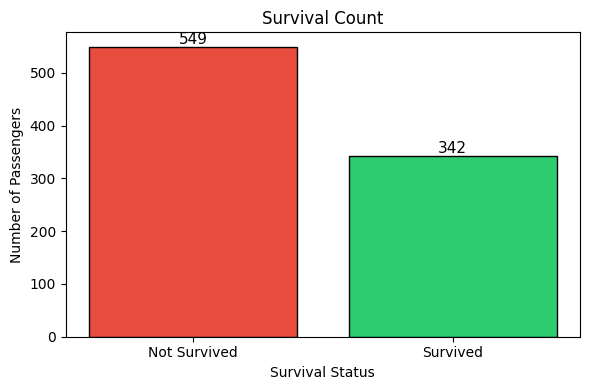

In [7]:
survival_counts = df['Survived'].value_counts()
labels = ['Not Survived', 'Survived']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, survival_counts, color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Survival Count')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(bar.get_height())),
             ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### **Survival by Gender**

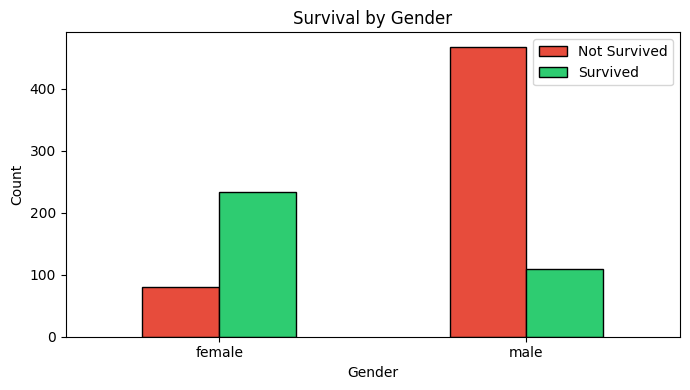

In [8]:
gender_survival = df.groupby('Sex')['Survived'].value_counts().unstack()

gender_survival.plot(kind='bar', color=['#e74c3c','#2ecc71'],
                     figsize=(7,4), edgecolor='black')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Not Survived','Survived'])
plt.tight_layout()
plt.show()

### **Survival by Passenger Class**

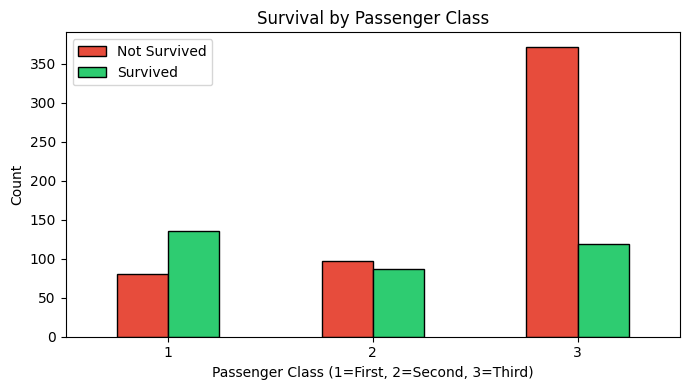

In [9]:
pclass_survival = df.groupby('Pclass')['Survived'].value_counts().unstack()

pclass_survival.plot(kind='bar', color=['#e74c3c','#2ecc71'],
                     figsize=(7,4), edgecolor='black')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Not Survived','Survived'])
plt.tight_layout()
plt.show()

### **Age Distribution**

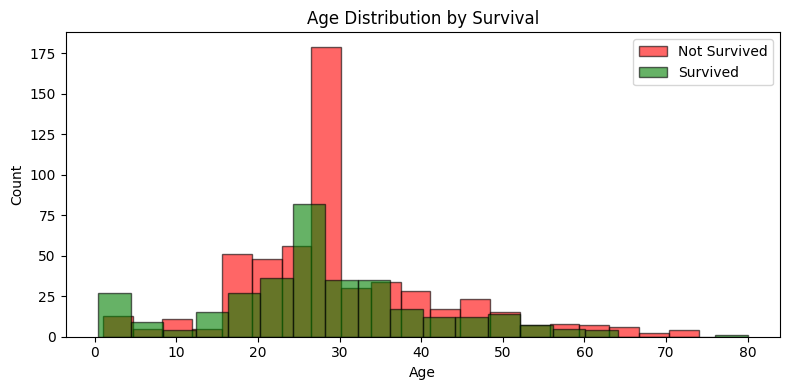

In [10]:
plt.figure(figsize=(8,4))
plt.hist(df[df['Survived']==0]['Age'], bins=20, alpha=0.6,
         color='red', edgecolor='black', label='Not Survived')
plt.hist(df[df['Survived']==1]['Age'], bins=20, alpha=0.6,
         color='green', edgecolor='black', label='Survived')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### **Fare Distribution**

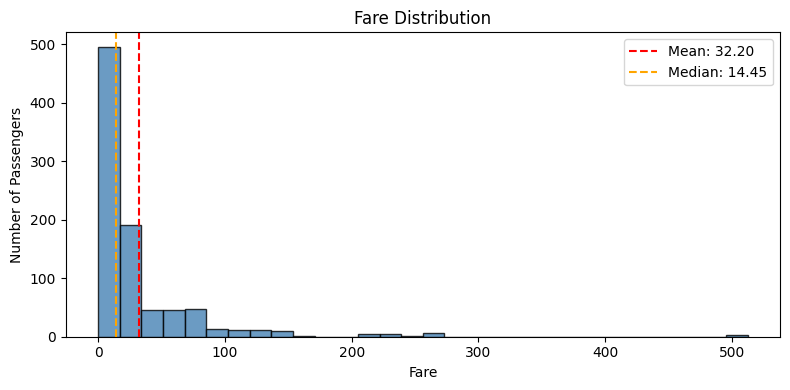

In [11]:
plt.figure(figsize=(8,4))
plt.hist(df['Fare'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.axvline(df['Fare'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Fare"].mean():.2f}')
plt.axvline(df['Fare'].median(), color='orange', linestyle='--',
            label=f'Median: {df["Fare"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### **Correlation Heatmap**

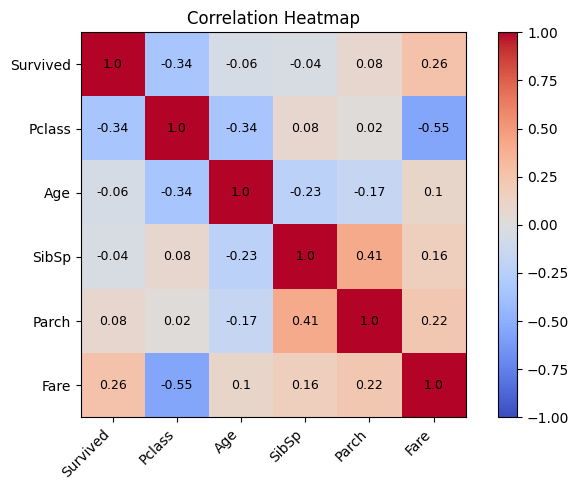

In [12]:
numeric_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare']]
corr = numeric_df.corr().round(2)

fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i,j], ha='center', va='center', fontsize=9)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### **Conclusions**

In [13]:
print("=" * 45)
print("        TITANIC EDA - KEY FINDINGS")
print("=" * 45)
print(f"Total Passengers   : {len(df)}")
print(f"Survived           : {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"Not Survived       : {(df['Survived']==0).sum()} ({(df['Survived']==0).mean()*100:.1f}%)")
print(f"\nFemale Survival    : {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Male Survival      : {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"\nClass 1 Survival   : {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"Class 2 Survival   : {df[df['Pclass']==2]['Survived'].mean()*100:.1f}%")
print(f"Class 3 Survival   : {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"\nAverage Age        : {df['Age'].mean():.1f} years")
print(f"Average Fare       : £{df['Fare'].mean():.2f}")
print("=" * 45)

        TITANIC EDA - KEY FINDINGS
Total Passengers   : 891
Survived           : 342 (38.4%)
Not Survived       : 549 (61.6%)

Female Survival    : 74.2%
Male Survival      : 18.9%

Class 1 Survival   : 63.0%
Class 2 Survival   : 47.3%
Class 3 Survival   : 24.2%

Average Age        : 29.4 years
Average Fare       : £32.20
